## Introduction<a id='introduction'></a>

**Purpose:**

Clean and explore data with univariate, bivariate plots

**Context:**

&emsp; Pickleball is an addictively fun racquet sport combining aspects of tennis, table tennis, and badminton and pickleball players are similarly diverse with players of all ages and all sports backgrounds. Players often spend hours on the courts both playing and socializing between games. A common topic of discussion amongst players is strategy with questions such as

* "Should I be dropping or driving my third shots?"
* "What kind of shots are more common at higher levels of play?"

This project aims to answer common questions in pickleball using data from pklmart.

**Data:**

Collection of pklmart data on Kaggle (https://www.kaggle.com/datasets/cakesofspan/pklmarts-competitive-pickleball-extracts). \
Pklmart (https://pklmart.com/)

**Outcomes from this notebook (Data Wrangling):**

1. Data comes in 6 tables housing game, player, team, rally, and shot data with the 6th table containing metadata for shot type.
2. Data collected into one primary dataframe and saved as shot_rally.csv
3. shot_rally is larely clean with nan values in player_id, next_loc_x, next_loc_y
    * nans in player_id inconsequential and at this point may not need data
    * nans in next_loc_x, next_loc_y are at the end of rallies
4. shot_rally positional data transformed for easy visualization on a pickleball court
    * serving team is always at the bottom (y=-22) while returning team is always at the top (y=22)
5. Plotted univariate distributions from game, rally, and shot dataframes
    * Distribution of skill according to self-reported rating nearly linear excluding a peak for 4.0; 4.0 most represented at 35.1% of games; roughly 44.9% of games are 4.0 and below;
    * 60% of players do not have a reported DUPR rating so subsetting by skill will be done using self-reported game level
    * Rally length roughly follows a Poisson distribution
        * would be interesting to fit and to fit for different skill levels and then extract the lambda value
    * Rally ending type mostly errors
    * The most common shot is a dink following by hands battle/volley; third shot drops are more common that third shot drives
    * The most common shot outcome other than starting and extending rallies is an error
        * Underscores how pickleball really is a game of minimizing errors
6. Plotted bivariate distributions as well
    * Rally length increases with skill level
        * Fit these to a skewed distribution, possibly Poisson, and compare fitted values
    * At the beginner level, 2.5 DUPR, the most common rally ending type is an unforced error; Across all other levels, excluding senior pro, the most common rally ending type is an error, but it is possible that these are a mix of forced and unforced errors
        * Again underscores how important it is to minimize errors
    * At the 4.5 level and above, the most common shot is the dink with hands battles coming in second by a large gap; Below 4.5, the most common shot is hands battle; 3.0 and below third shot drives are more common than third shot drops while drops are favored for 3.5 and above; It appears that at 4.5 and above, players are getting to the net more frequently and dinking becomes more important


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Andy's path to project data folder
data_path = '/content/drive/MyDrive/Colab Notebooks/DSCI 521 Final Project (Pickleball Analytics)/data/'

plt.rcParams.update({'font.size': 16})

## To-Do:

1. Can we make an estimate of how a game may have gone differently if a player chooses to be more or less aggressive?
2. Looking at distribution of winner, error, unforced error according to shot type
3. Distribution of next shot vs current shot, and distribution of next 2 shots (would be your next shot) vs current shot (Split accourding to DUPR)
4. Clean data
5. Create master dataframe to do most of analysis

Method:
1. First create a history of shots and outcomes for a given player.
2. Establish profile of aggressive/defensive  by considering the shots choices made by the player.
3. Tune player shot profile to be more aggressive/defensive, then simulate games using history of shots.
4. Compare results of simulations for more aggressive/defensive playstyles.
5. Understand data

## Contents<a id='contents'></a>
* [Introduction](#introduction)
* [Contents](#contents)
* [Objectives](#objectives)
* [Cleaning Data](#cleaning_data)
* [Exploring Data](#exploring_data)
* [Sources](#sources)

<!-- * [Summary](#summary)     -->

## Objectives

1. Load and make sense of pklmart data
2. Clean pklmart data
3. Establish clear project objective
4. Figure out project endpoint and deliverable

## Cleaning Data<a id='cleaning_data'></a>

Data comes from pklmart, hosted on Kaggle. Includes 7 tables.


In [11]:
game_df = pd.read_csv(data_path+'raw/game.csv')
player_df = pd.read_csv(data_path+'raw/player.csv')
team_df = pd.read_csv(data_path+'raw/team.csv')
rally_df = pd.read_csv(data_path+'raw/rally.csv')
shot_df = pd.read_csv(data_path+'raw/shot.csv')
shot_type_ref = pd.read_csv(data_path+'raw/shot_type_ref.csv')

### Game Data<a id='game_data'></a>

Missing 0.107% of `ball_type` data. Since ball type has a minor effect match, will not be concerned with this field

**Result:**
* Game data is largely clean

In [ ]:
print(game_df.shape)
game_df.head()

(935, 11)


,game_id,match_id,game_nbr,score_w,score_l,w_team_id,l_team_id,skill_lvl,scoring_type,ball_type,dt_played
0,G347,M219,1,12,10,T311,T310,Pro,STANDARD_DOUBLES,D40,2022-10-25
1,G481,M317,1,5,5,T391,T390,4.0,STANDARD_DOUBLES,U,2023-10-01
2,G361,M227,1,15,9,T159,T321,3.5,STANDARD_DOUBLES,FX40,2023-10-21
3,G107,M54,1,11,4,T78,T82,4.5,STANDARD_DOUBLES,U,2023-02-25
4,G104,M52,1,11,5,T78,T79,4.5,STANDARD_DOUBLES,U,2023-02-25


In [ ]:
game_df.isnull().sum()/game_df.shape[0]*100

game_id         0.000000
match_id        0.000000
game_nbr        0.000000
score_w         0.000000
score_l         0.000000
w_team_id       0.000000
l_team_id       0.000000
skill_lvl       0.000000
scoring_type    0.000000
ball_type       0.106952
dt_played       0.000000
dtype: float64

In [ ]:
print('Number of unique game IDs: ',game_df['game_id'].nunique())

Number of unique game IDs:  935


### Player Data<a id='player_data'></a>

Missing 0.217% of data for `gender, dom_hand` \
Missing 59.7% of data for `doublesreliabilityscore` \
Missing 60.0% of data for `doubles_dupr`

**Result:**
* Missing 60.0% of data for `doubles_dupr` and only 29.1% of players have a `doubles_dupr` with a reliability score over 50
  * Can try to impute missing dupr scores by taking an average or mode from their games

In [ ]:
print(player_df.shape)
player_df.head()

(923, 5)


,player_id,gender,dom_hand,doubles_dupr,doublesreliabilityscore
0,P699,M,L,NaN,NaN
1,P600,M,R,4.101,5.0
2,P472,M,R,NaN,NaN
3,P320,M,R,NaN,0.0
4,P290,M,L,3.967,1.0


In [ ]:
player_df.isnull().sum()/player_df.shape[0]*100

player_id                   0.000000
gender                      0.216685
dom_hand                    0.216685
doubles_dupr               60.021668
doublesreliabilityscore    59.696641
dtype: float64

In [ ]:
player_df[player_df['doublesreliabilityscore'] > 50].shape[0]/player_df.shape[0]*100

29.144095341278444

C:\Users\kimvo\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='doubles_dupr', ylabel='Count'>

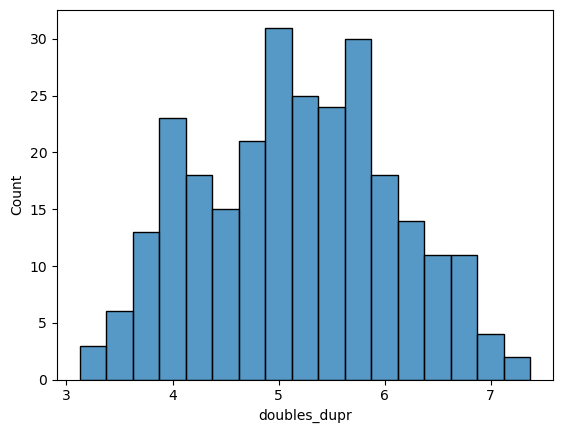

In [ ]:
sns.histplot(player_df[player_df['doublesreliabilityscore'] > 50], x='doubles_dupr', binwidth=0.25)

### Team Data<a id='team_data'></a>

Team data does not contain null values

In [ ]:
print(team_df.shape)
team_df.head()

(1590, 3)


,team_id,player_id,player_seq_nbr
0,T3,P5,1
1,T3,P2,2
2,T5,P8,1
3,T5,P9,2
4,T7,P12,1


In [ ]:
team_df.isnull().sum()/team_df.shape[0]*100

team_id           0.0
player_id         0.0
player_seq_nbr    0.0
dtype: float64

### Rally Data<a id='rally_data'></a>

Missing 0.931% of data in `w_team_id, srv_player_id, rtrn_player_id, srv_team_flipped_ind, rtrn_team_flipped_ind` \
Missing 1.25% of data in `rally_len` \
Missing 8.06% of data in `ts_type` \
Missing 8.90% of data in `ending_player_id` \
Missing 20.3% of data in `ts_player_id` \
Missing 99.1% of data in `to_team_id`


**Result:**
* Fields with 0.931% of missing data are from the same records
  * Explore if those data are compromised, but likely can drop these rallies
* Try to fill in missing `rally_len` by consulting shot data
* Try to fill in missing `ts_type` by consulting shot data
* Missing data in `ts_player_id` and `to_team_id` are not concerning

In [ ]:
print(rally_df.shape)
rally_df.head()

(40702, 24)


,rally_id,game_id,match_id,rally_nbr,w_team_id,srv_team_id,srv_player_id,rtrn_team_id,rtrn_player_id,ts_player_id,...,ending_type,ending_player_id,srv_switch_ind,rtrn_switch_ind,srv_team_flipped_ind,rtrn_team_flipped_ind,srv_team_rs_player_id,srv_team_ls_player_id,rtrn_team_rs_player_id,rtrn_team_ls_player_id
0,R8968,G208,M113,6,T152,T152,P202,T155,P70,P202,...,Other,NaN,Y,N,N,N,P203,P202,P70,P205
1,R8963,G208,M113,1,T155,T152,P202,T155,P70,NaN,...,Error,P203,Y,N,N,N,P203,P202,P70,P205
2,R8964,G208,M113,2,T152,T155,P70,T152,P202,P205,...,Error,P205,N,Y,N,N,P70,P205,P203,P202
3,R8965,G208,M113,3,T155,T155,P205,T152,P203,P205,...,Error,P203,N,Y,N,N,P70,P205,P203,P202
4,R8966,G208,M113,4,T155,T155,P205,T152,P202,P70,...,Winner,P205,Y,Y,Y,N,P70,P205,P203,P202


In [ ]:
rally_df.isnull().sum()/rally_df.shape[0]*100

,0
rally_id,0.000000
game_id,0.000000
match_id,0.000000
rally_nbr,0.000000
w_team_id,0.931158
srv_team_id,0.000000
srv_player_id,0.931158
rtrn_team_id,0.000000
rtrn_player_id,0.931158
ts_player_id,20.342981


In [ ]:
rally_df['ts_type'].value_counts()

,count
ts_type,
Drop,20152
Drive,16660
Lob,608


<Axes: >

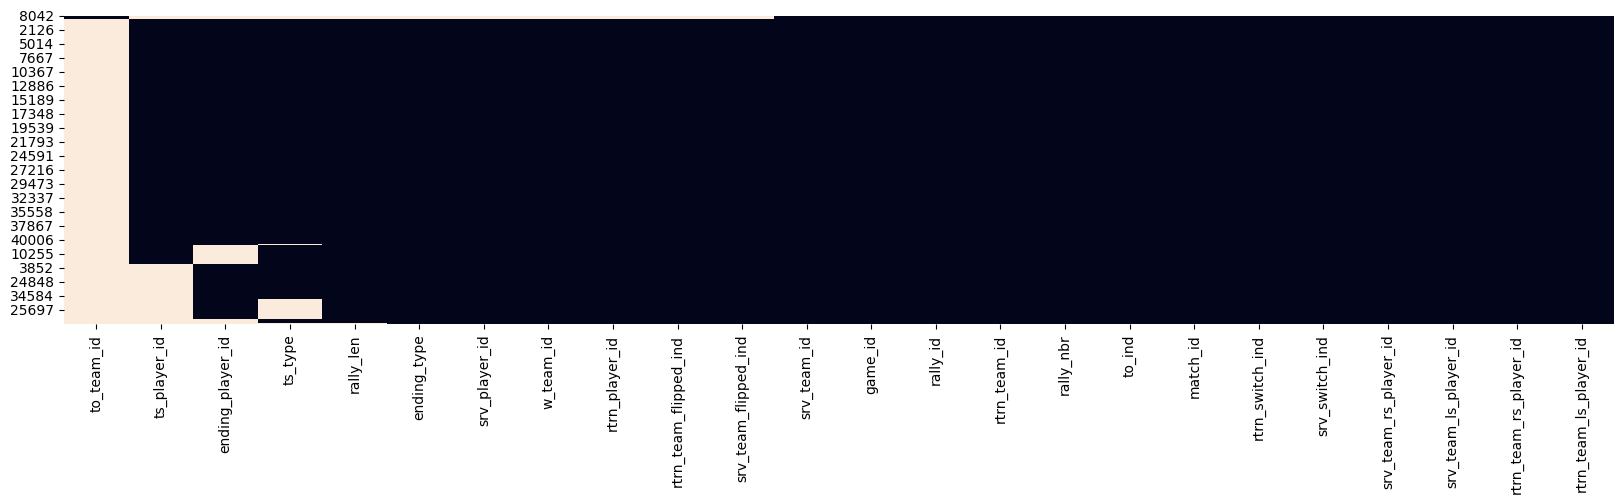

In [ ]:
cols=list(rally_df.notnull().sum().sort_values().index)
plt.figure(figsize=(20,4))
sns.heatmap(rally_df[cols].isnull().sort_values(by=cols), cbar=False)

### Shot Data<a id='shot_data'></a>

Missing 0.004% of `shot_type` \
Missing 0.025% of `player_id` \
Missing 0.028% of `loc_y` \
Missing 4.02% of `next_loc_x, next_loc_y`

**Result:**
* Explore why missing data for `next_loc_x, next_loc_y`
* Explore why missing data for `loc_y` but not for `loc_x`
* Try to fill in `shot_type` by looking at `next_loc_x, next_loc_y`
* Data is relatively clean but see if we can fill in some missing values

In [6]:
shot_df = pd.read_csv(data_path+'raw/shot.csv')
print(shot_df.shape)
shot_df.head()

(304649, 9)


,shot_id,rally_id,shot_nbr,shot_type,player_id,loc_x,loc_y,next_loc_x,next_loc_y
0,S213113,R26079,2,R,P582,18.35,23.70,18.64,21.59
1,S237646,R29288,3,tsDrv,P670,13.68,21.77,11.84,0.00
2,S213112,R26079,1,SE,P197,13.40,22.32,18.35,23.70
3,S213152,R26086,1,SE,P488,5.60,22.97,3.29,24.25
4,S213210,R26092,2,R,P488,5.50,20.58,9.81,12.03


In [ ]:
shot_df.isnull().sum()/shot_df.shape[0]*100

,0
shot_id,0.000000
rally_id,0.000000
shot_nbr,0.000000
shot_type,0.003939
player_id,0.024947
loc_x,0.000000
loc_y,0.027573
next_loc_x,4.020036
next_loc_y,4.020036


Now doing the actual cleaning.

First re-sort `shot_df` according to `rally_id, shot_nbr` and assigning new index.

Next, filling in null values for `loc_y`

In [17]:
shot_df = pd.read_csv(data_path+'raw/shot.csv')

shot_df.sort_values(['rally_id', 'shot_nbr'], inplace=True)
shot_df.reset_index(drop=True, inplace=True)

In [18]:
shot_df.head(10)

,shot_id,rally_id,shot_nbr,shot_type,player_id,loc_x,loc_y,next_loc_x,next_loc_y
0,S10554,R1000,1,SE,P13,16.74,20.17,15.82,22.80
1,S10555,R1000,2,R,P6,15.82,22.80,3.11,20.85
2,S10556,R1000,3,tsDrp,P23,3.11,20.85,7.12,7.56
3,S10557,R1000,4,tzRep,P6,7.12,7.56,8.72,18.56
4,S10558,R1000,5,tzApp,P13,8.72,18.56,5.86,7.79
5,S10559,R1000,6,HB,P24,5.86,7.79,-2.40,16.16
6,S10560,R1000,7,tzApp,P23,-2.40,16.16,15.14,8.82
7,S10561,R1000,8,HB,P24,15.14,8.82,3.33,19.48
8,S10562,R1000,9,HB,P23,3.33,19.48,NaN,NaN
9,S91499,R10000,1,SE,P256,8.07,21.95,5.32,20.03


In [19]:
my_df = shot_df[shot_df['loc_y'].isnull()]
my_df[my_df['shot_nbr'] == 1]

,shot_id,rally_id,shot_nbr,shot_type,player_id,loc_x,loc_y,next_loc_x,next_loc_y
68671,S168432,R20417,1,SE,P479,10.0,NaN,NaN,NaN


In [20]:
# for rally_id R20417, setting loc_y to 23.0, outcome was unforced error.
# server likely missed the serve
my_ind = my_df[my_df['shot_nbr'] == 1].index
my_df.loc[my_ind, 'loc_y'] = 23.0
shot_df.loc[my_ind, 'loc_y'] = 23.0

Going through each rally where `loc_y` is null and seeing if can extract position from previous rally

In [21]:
my_df = shot_df[shot_df['loc_y'].isnull()]

In [22]:
my_df.index

Index([ 15744,  17234,  17910,  17930,  22932,  23219,  52649,  52807,  55582,
        58417,  58427,  58430,  58442,  58528,  58560,  59416,  60373,  62492,
        62932,  62995,  63083,  64962,  65139,  65310,  66554,  68812,  85988,
        86012,  86760,  88632, 110844, 115018, 116299, 118318, 127015, 127502,
       127768, 134784, 134830, 135813, 136175, 155612, 165416, 175456, 176595,
       203486, 281310, 285438, 287741, 287743, 287745, 287833, 287938, 292717,
       292718, 292719, 292720, 292721, 292722, 292723, 292724, 292822, 292823,
       292824, 292825, 292826, 292827, 292828, 292829, 292830, 292831, 292975,
       292976, 292977, 293189, 293190, 293191, 293192, 293193, 293289, 293353,
       297210, 302498],
      dtype='int64')

In [23]:
shot_df.head(10)

,shot_id,rally_id,shot_nbr,shot_type,player_id,loc_x,loc_y,next_loc_x,next_loc_y
0,S10554,R1000,1,SE,P13,16.74,20.17,15.82,22.80
1,S10555,R1000,2,R,P6,15.82,22.80,3.11,20.85
2,S10556,R1000,3,tsDrp,P23,3.11,20.85,7.12,7.56
3,S10557,R1000,4,tzRep,P6,7.12,7.56,8.72,18.56
4,S10558,R1000,5,tzApp,P13,8.72,18.56,5.86,7.79
5,S10559,R1000,6,HB,P24,5.86,7.79,-2.40,16.16
6,S10560,R1000,7,tzApp,P23,-2.40,16.16,15.14,8.82
7,S10561,R1000,8,HB,P24,15.14,8.82,3.33,19.48
8,S10562,R1000,9,HB,P23,3.33,19.48,NaN,NaN
9,S91499,R10000,1,SE,P256,8.07,21.95,5.32,20.03


In [ ]:
# All shots where loc_y is null contain a previous shot.
# Pulling loc_y from next_loc_y of previous shot
inds = my_df.index

for i in inds:
    shot_df.loc[i, 'loc_y'] = shot_df.loc[i-1, 'next_loc_y']

In [ ]:
shot_df.isnull().sum()

,0
shot_id,0
rally_id,0
shot_nbr,0
shot_type,12
player_id,76
loc_x,0
loc_y,0
next_loc_x,12247
next_loc_y,12247


Now filling in nans for `next_loc_x, next_loc_y`

nans for `next_loc_x, next_loc_y` are in pairs, if nan for one then nan for other

In [ ]:
m1 = shot_df['next_loc_x'].isnull()
m2 = shot_df['next_loc_y'].isnull()

mask = [(x or y) for x,y in zip(m1, m2)]
my_df = shot_df[mask]

In [ ]:
my_df

,shot_id,rally_id,shot_nbr,shot_type,player_id,loc_x,loc_y,next_loc_x,next_loc_y
8,S10562,R1000,9,HB,P23,3.33,19.48,NaN,NaN
18,S91508,R10000,10,HB,P194,-1.48,14.70,NaN,NaN
55,S91548,R10004,7,HB,P194,15.60,2.85,NaN,NaN
60,S91553,R10005,5,HB,P197,4.39,1.65,NaN,NaN
107,S10591,R1001,29,HB,P13,15.14,1.26,NaN,NaN
...,...,...,...,...,...,...,...,...,...
304575,S10553,R999,24,D,P24,15.02,1.72,NaN,NaN
304583,S91427,R9990,8,HB,P197,-1.75,2.94,NaN,NaN
304629,S91478,R9996,9,HB,P197,11.93,21.59,NaN,NaN
304642,S91492,R9998,8,HB,P257,4.40,1.38,NaN,NaN


In [ ]:
# for each pair of nans, check to see if there is a valid subsequent shot
# if there is, then pull values from there
inds = my_df.index

for i in inds:
    if i+1 < len(shot_df):
        if (shot_df.loc[i+1, 'shot_nbr'] == shot_df.loc[i, 'shot_nbr'] + 1):
            shot_df.loc[i, 'next_loc_x'] = shot_df.loc[i+1, 'loc_x']
            shot_df.loc[i, 'next_loc_y'] = shot_df.loc[i+1, 'loc_y']

In [ ]:
# remaining nans should be from last shots, double check that this is true
m1 = shot_df['next_loc_x'].isnull()
m2 = shot_df['next_loc_y'].isnull()

mask = [(x or y) for x,y in zip(m1, m2)]
my_df = shot_df[mask]

In [ ]:
inds = my_df.index
last_shot = []

for i in inds:
    if i + 1 < len(shot_df):
        if shot_df.loc[i, 'rally_id'] != shot_df.loc[i+1, 'rally_id']:
            last_shot.append(True)
        else:
            last_shot.append(False)

In [ ]:
# yes, all remaining nans on next_loc_x, next_loc_y are found in the last shot
print(len(my_df), sum(last_shot))

11818 11817


In [ ]:
# saving progress
shot_df.to_csv(data_path+'interim/shot.csv', index=False)

In [ ]:
# loading progress
shot_df = pd.read_csv(data_path+'interim/shot.csv')

In [ ]:
# Now attempting to fill nans in shot_type
my_df = shot_df[shot_df['shot_type'].isnull()]
my_df

,shot_id,rally_id,shot_nbr,shot_type,player_id,loc_x,loc_y,next_loc_x,next_loc_y
58388,S156056,R17899,3,NaN,P473,-1.57,16.63,NaN,NaN
58399,S156059,R17900,3,NaN,P472,8.99,18.19,NaN,NaN
58402,S156062,R17901,3,NaN,P472,-4.51,18.10,NaN,NaN
58427,S156087,R17905,3,NaN,P472,3.85,0.00,NaN,NaN
58430,S156090,R17906,3,NaN,P473,1.28,0.00,NaN,NaN
58441,S156101,R17909,3,NaN,P470,7.79,21.68,13.77,0.00
58539,S156181,R17924,3,NaN,P472,6.97,23.15,NaN,NaN
58547,S156189,R17926,3,NaN,P471,11.01,23.42,NaN,NaN
88851,S191883,R23447,13,NaN,P62,18.55,12.03,NaN,NaN
136899,S242484,R29852,9,NaN,P411,10.18,10.93,NaN,NaN


In [ ]:
# Referencing rally_df to check ending_type. ending_type can inform
# shot_type of shot_df where next_loc_x, next_loc_y are nans
r_ids = my_df.rally_id
indices = []

for r_id in r_ids:
    indices.append(rally_df[rally_df['rally_id'] == r_id].index.values[0])
rally_df.loc[indices, ['rally_id', 'srv_team_id', 'rtrn_team_id', 'ts_type',
                       'rally_nbr', 'rally_len', 'ending_type', 'game_id']]

,rally_id,srv_team_id,rtrn_team_id,ts_type,rally_nbr,rally_len,ending_type,game_id
13388,R17899,T360,T359,NaN,9,3.0,Error,G418
13389,R17900,T360,T359,NaN,10,3.0,NaN,G418
13390,R17901,T360,T359,NaN,11,3.0,Error,G418
13394,R17905,T360,T359,NaN,15,3.0,Error,G418
13395,R17906,T360,T359,NaN,16,3.0,Unforced Error,G418
13410,R17909,T359,T360,NaN,19,4.0,Unforced Error,G418
13398,R17924,T360,T359,NaN,34,3.0,Error,G418
13418,R17926,T359,T360,NaN,36,3.0,Error,G418
17780,R23447,T320,T446,Drop,7,13.0,Other,G554
23406,R29852,T560,T559,Drive,36,9.0,Other,G701


In [ ]:
my_df.index[:-1]

Index([58388, 58399, 58402, 58427, 58430, 58441, 58539, 58547, 88851, 136899,
       230357],
      dtype='int64')

In [ ]:
# For all rally_ids except for R50853, the shots resulted in an error
# since the result was an error, cannot determine shot_type. Converting to U
inds = my_df.index[:-1]

for i in inds:
    shot_df.loc[i, 'shot_type'] = 'U'

In [ ]:
# to fill last nan in shot_type, referencing other shots in rally
# Since previous shot was a drop and the next was a HB, shot was likely a SP
shot_df[shot_df['rally_id'] == 'R50853']

,shot_id,rally_id,shot_nbr,shot_type,player_id,loc_x,loc_y,next_loc_x,next_loc_y
273838,S421620,R50853,1,SE,P866,13.12,20.67,15.24,19.02
273839,S421621,R50853,2,R,P869,15.24,19.02,3.01,21.40
273840,S421622,R50853,3,tsDrp,P990,3.01,21.40,16.99,7.17
273841,S421623,R50853,4,NaN,P869,16.99,7.17,3.66,7.26
273842,S421624,R50853,5,HB,P990,3.66,7.26,15.88,7.44
273843,S421625,R50853,6,HB,P869,15.88,7.44,8.16,22.23


In [ ]:
shot_df.loc[273841, 'shot_type'] = 'SP'

In [ ]:
shot_df.isnull().sum()

,0
shot_id,0
rally_id,0
shot_nbr,0
shot_type,0
player_id,76
loc_x,0
loc_y,0
next_loc_x,11818
next_loc_y,11818


In [ ]:
# remaining nulls are in player_id and next_loc_x, next_loc_x
# nulls in player_id likely not important and know nulls in
# next_loc_x and next_loc_y are for the last rally where the rally has ended
# saving shot_df. Saving interim again.
# Largely clean, adding shot_outcome and whether serving team won the point
shot_df.to_csv(data_path+'interim/shot.csv', index=False)

In [ ]:
shot_df = pd.read_csv(data_path+'interim/shot.csv')

In [ ]:
shot_df.head()

,shot_id,rally_id,shot_nbr,shot_type,player_id,loc_x,loc_y,next_loc_x,next_loc_y
0,S10554,R1000,1,SE,P13,16.74,20.17,15.82,22.80
1,S10555,R1000,2,R,P6,15.82,22.80,3.11,20.85
2,S10556,R1000,3,tsDrp,P23,3.11,20.85,7.12,7.56
3,S10557,R1000,4,tzRep,P6,7.12,7.56,8.72,18.56
4,S10558,R1000,5,tzApp,P13,8.72,18.56,5.86,7.79


In [ ]:
# merging tables to create master sheet
rally_cols = ['rally_id', 'game_id', 'match_id', 'rally_nbr', 'rally_len',
              'w_team_id', 'srv_team_id', 'rtrn_team_id', 'ending_type']
shot_rally_df = pd.merge(shot_df, rally_df[rally_cols], on='rally_id', how='left')

In [ ]:
new_order = ['match_id', 'game_id', 'rally_id', 'rally_nbr', 'rally_len',
             'srv_team_id', 'rtrn_team_id', 'w_team_id', 'shot_id',
             'shot_nbr', 'shot_type', 'player_id', 'loc_x', 'loc_y',
             'next_loc_x', 'next_loc_y', 'ending_type']
shot_rally_df = shot_rally_df[new_order]
shot_rally_df.sort_values(['match_id', 'game_id', 'rally_nbr', 'shot_nbr'],
                          inplace=True, ascending=False)
shot_rally_df = shot_rally_df.astype({'rally_len':'int64'})

In [ ]:
# finding and removing incomplete rallies
# identifying incomplete rallies if rally_len does not match the number of shots
inds = shot_rally_df.index
prev_rally_id = shot_rally_df.loc[inds[0], 'rally_id']
incomplete_rallies = []
cur_shot_count = 0

# loop through shot_rally_df
for i, ind in enumerate(inds):
    cur_rally_id = shot_rally_df.loc[ind, 'rally_id']
    # if enter new rally, check if shot_count matches rally_len of prev rally
    if cur_rally_id != prev_rally_id:
        # if shot_count does not match, then add to list of incomplete rallies
        if cur_shot_count != shot_rally_df.loc[inds[i-1], 'rally_len']:
            incomplete_rallies.append(prev_rally_id)
        # either case, start tracking for new rally_id
        prev_rally_id = cur_rally_id
        cur_shot_count = 1
    # if in same rally, increment cur_shot_count
    else:
        cur_shot_count += 1

# now removing incomplete rallies
incomplete_rally_mask = []
for i in shot_rally_df.index:
    if shot_rally_df.loc[i, 'rally_id'] in incomplete_rallies:
        incomplete_rally_mask.append(False)
    else:
        incomplete_rally_mask.append(True)

shot_rally_df = shot_rally_df[incomplete_rally_mask]

In [ ]:
# need to convert ending_type to shot_outcome. As is, ending_type applies only
# last shot in the rally
# need to convert w_team_id to something like rally_outcome where values are
# point, next serve, or sideout
# consider adding or modifying player_id to include which team they belong on
shot_rally_df.head(20)

,match_id,game_id,rally_id,rally_nbr,rally_len,srv_team_id,rtrn_team_id,w_team_id,shot_id,shot_nbr,shot_type,player_id,loc_x,loc_y,next_loc_x,next_loc_y,ending_type
289847,M99,G178,R7807,65,4,T135,T136,T135,S72059,4,HB,P183,6.05,8.08,NaN,NaN,Unforced Error
289846,M99,G178,R7807,65,4,T135,T136,T135,S72058,3,tsDrv,P182,11.29,20.58,6.05,8.08,Unforced Error
289845,M99,G178,R7807,65,4,T135,T136,T135,S72057,2,R,P184,17.53,20.76,11.29,20.58,Unforced Error
289844,M99,G178,R7807,65,4,T135,T136,T135,S72056,1,SE,P181,12.58,20.94,17.53,20.76,Unforced Error
289843,M99,G178,R7806,64,4,T135,T136,T135,S72055,4,HB,P184,11.56,7.72,NaN,NaN,Unforced Error
289842,M99,G178,R7806,64,4,T135,T136,T135,S72054,3,tsDrv,P181,5.04,19.84,11.56,7.72,Unforced Error
289841,M99,G178,R7806,64,4,T135,T136,T135,S72053,2,R,P183,2.74,20.58,5.04,19.84,Unforced Error
289840,M99,G178,R7806,64,4,T135,T136,T135,S72052,1,SE,P181,4.40,21.04,2.74,20.58,Unforced Error
289839,M99,G178,R7805,63,8,T135,T136,T135,S72051,8,HB,P183,3.38,7.90,NaN,NaN,Unforced Error
289838,M99,G178,R7805,63,8,T135,T136,T135,S72050,7,Res,P182,11.38,20.30,3.38,7.90,Unforced Error


In [ ]:
shot_rally_df.ending_type.unique()

array(['Unforced Error', 'Winner', 'Error', 'Other', nan], dtype=object)

In [ ]:
# shot_outcome can be winner, extend rally, force error, create opportunity,
# pop up, or unforced error
my_df = shot_rally_df
shot_outcome = []

inds = my_df.index
for i in range(len(inds)):
    if my_df.loc[inds[i], 'shot_nbr'] == my_df.loc[inds[i], 'rally_len']:
        shot_outcome.append(my_df.loc[inds[i], 'ending_type'])
    elif shot_outcome[-1] == 'Pop Up':
        shot_outcome.append('Create Opportunity')
    else:
        if shot_outcome[-1] == 'Error':
            shot_outcome.append('Force Error')
        elif my_df.loc[inds[i-1], 'shot_type'] == 'HB' and my_df.loc[inds[i], 'shot_type'] == 'D':
            shot_outcome.append('Pop Up')
        elif my_df.loc[inds[i], 'shot_type'] == 'SE':
            shot_outcome.append('Start Rally')
        elif my_df.loc[inds[i], 'shot_type'] == 'tsDrv' and shot_outcome[-1] in ['Unforced Error', 'Error']:
            shot_outcome.append('Winner')
        elif my_df.loc[inds[i], 'shot_type'] == 'SP':
            cond1 = my_df.loc[inds[i], 'shot_nbr'] + 2 == my_df.loc[inds[i], 'rally_len']
            cond2 = my_df.loc[inds[i-2], 'ending_type'] == 'Winner'
            if cond1 and cond2:
                shot_outcome.append('Create Opportunity')
            elif my_df.loc[inds[i-1], 'ending_type'] == 'Winner':
                shot_outcome.append('Lose Rally')
            elif my_df.loc[inds[i-1], 'shot_type'] == 'HB':
                shot_outcome.append('Initiate Hands Battle')
            else:
                shot_outcome.append('Speed Up')
        else:
            shot_outcome.append('Extend Rally')
shot_rally_df['shot_outcome'] = shot_outcome

In [ ]:
shot_rally_df[100:150]

,match_id,game_id,rally_id,rally_nbr,rally_len,srv_team_id,rtrn_team_id,w_team_id,shot_id,shot_nbr,shot_type,player_id,loc_x,loc_y,next_loc_x,next_loc_y,ending_type,shot_outcome
289744,M99,G178,R7796,54,20,T135,T136,T135,S71959,2,R,P183,5.22,21.59,5.23,19.84,Unforced Error,Extend Rally
289743,M99,G178,R7796,54,20,T135,T136,T135,S71958,1,SE,P182,6.79,20.67,5.22,21.59,Unforced Error,Start Rally
289742,M99,G178,R7795,53,17,T135,T136,T136,S71957,17,D,P182,15.24,8.45,NaN,NaN,Unforced Error,Unforced Error
289741,M99,G178,R7795,53,17,T135,T136,T136,S71956,16,D,P184,17.44,7.90,15.24,8.45,Unforced Error,Extend Rally
289740,M99,G178,R7795,53,17,T135,T136,T136,S71955,15,D,P182,13.86,7.90,17.44,7.90,Unforced Error,Extend Rally
289739,M99,G178,R7795,53,17,T135,T136,T136,S71954,14,D,P184,12.29,8.45,13.86,7.90,Unforced Error,Extend Rally
289738,M99,G178,R7795,53,17,T135,T136,T136,S71953,13,tzApp,P182,11.75,15.34,12.29,8.45,Unforced Error,Extend Rally
289737,M99,G178,R7795,53,17,T135,T136,T136,S71952,12,tzRep,P183,7.88,9.00,11.75,15.34,Unforced Error,Extend Rally
289736,M99,G178,R7795,53,17,T135,T136,T136,S71951,11,tzApp,P182,14.32,14.79,7.88,9.00,Unforced Error,Extend Rally
289735,M99,G178,R7795,53,17,T135,T136,T136,S71950,10,SP,P183,2.10,9.46,14.32,14.79,Unforced Error,Speed Up


In [ ]:
shot_rally_df.to_csv(data_path+'interim/shot_rally.csv', index=True)

In [ ]:
shot_rally_df = pd.read_csv(data_path+'interim/shot_rally.csv', index_col=0)

In [ ]:
# rally_outcome can be point, next server, sideout, game over
my_df = shot_rally_df
# initializing 0
# since descending order, first row is always game over
rally_outcome = ['Game Over']

inds = my_df.index
prev_rally_id = my_df.iloc[0]['rally_id']
prev_game_id = my_df.iloc[0]['game_id']
for i in range(1, len(inds)):
    cur_rally_id = my_df.loc[inds[i], 'rally_id']
    cur_game_id = my_df.loc[inds[i], 'game_id']
    # if new game, then push game over since descending order
    if cur_game_id != prev_game_id:
        rally_outcome.append('Game Over')
        # update prev_game_id and prev_rally_id
        prev_game_id = cur_game_id
        prev_rally_id = cur_rally_id
    # if in the same rally, then continue pushing the outcome until we hit a new rally
    elif cur_rally_id == prev_rally_id:
        rally_outcome.append(rally_outcome[-1])
    else:
        # same game, at the end of a new rally since descending
        if my_df.loc[inds[i], 'srv_team_id'] == my_df.loc[inds[i], 'w_team_id']:
            rally_outcome.append('Point')
        # if serving team did not win rally, can either be next server or side out
        else:
            # if new serving team relative to last rally, then side out
            if my_df.loc[inds[i-1], 'srv_team_id'] != my_df.loc[inds[i], 'srv_team_id']:
                rally_outcome.append('Side Out')
            else:
                rally_outcome.append('Next Server')
        prev_rally_id = cur_rally_id

shot_rally_df['rally_outcome'] = rally_outcome

In [ ]:
shot_rally_df[:10]

,match_id,game_id,rally_id,rally_nbr,rally_len,srv_team_id,rtrn_team_id,w_team_id,shot_id,shot_nbr,shot_type,player_id,loc_x,loc_y,next_loc_x,next_loc_y,ending_type,shot_outcome,rally_outcome
289847,M99,G178,R7807,65,4,T135,T136,T135,S72059,4,HB,P183,6.05,8.08,NaN,NaN,Unforced Error,Unforced Error,Game Over
289846,M99,G178,R7807,65,4,T135,T136,T135,S72058,3,tsDrv,P182,11.29,20.58,6.05,8.08,Unforced Error,Winner,Game Over
289845,M99,G178,R7807,65,4,T135,T136,T135,S72057,2,R,P184,17.53,20.76,11.29,20.58,Unforced Error,Extend Rally,Game Over
289844,M99,G178,R7807,65,4,T135,T136,T135,S72056,1,SE,P181,12.58,20.94,17.53,20.76,Unforced Error,Start Rally,Game Over
289843,M99,G178,R7806,64,4,T135,T136,T135,S72055,4,HB,P184,11.56,7.72,NaN,NaN,Unforced Error,Unforced Error,Point
289842,M99,G178,R7806,64,4,T135,T136,T135,S72054,3,tsDrv,P181,5.04,19.84,11.56,7.72,Unforced Error,Winner,Point
289841,M99,G178,R7806,64,4,T135,T136,T135,S72053,2,R,P183,2.74,20.58,5.04,19.84,Unforced Error,Extend Rally,Point
289840,M99,G178,R7806,64,4,T135,T136,T135,S72052,1,SE,P181,4.40,21.04,2.74,20.58,Unforced Error,Start Rally,Point
289839,M99,G178,R7805,63,8,T135,T136,T135,S72051,8,HB,P183,3.38,7.90,NaN,NaN,Unforced Error,Unforced Error,Point
289838,M99,G178,R7805,63,8,T135,T136,T135,S72050,7,Res,P182,11.38,20.30,3.38,7.90,Unforced Error,Extend Rally,Point


In [ ]:
# Fill nans in ending_type and shot_outcome with Unknown
shot_rally_df.fillna(value={'ending_type':'Unknown', 'shot_outcome':'Unknown'},
                     inplace=True)

In [ ]:
# Next need to convert coordinates
shot_rally_df.to_csv(data_path+'interim/shot_rally.csv', index=True)

### Transforming Shot Data

Applying general transformations including
* Sorting by rally_id, shot_nbr
* Changing coordinate systems

For `rally_df` add a column if they earned a point or if went to 2nd server or if side out

In [ ]:
def change_coordinate_system(df: pd.DataFrame) -> pd.DataFrame:
    '''
    Purpose is to change coordinate system of loc_x, loc_y, next_loc_x, next_loc_y
    such that the net is at (0, 0) to (20, 0), the serving team starts at y=-22,
    and the returning team starts at y=22. See plotting function for visualization
    of rallies
    Inputs:
        df: shots dataframe; pd.DataFrame
    Outputs:
        df: shots dataframe; pd.DataFrame
    '''
    inds = df.index
    for i in inds:
        if df.loc[i, 'shot_nbr'] % 2 == 1:
            df.loc[i, 'loc_x'] = 20 - df.loc[i, 'loc_x']
            df.loc[i, 'loc_y'] = -df.loc[i, 'loc_y']
        else:
            df.loc[i, 'next_loc_x'] = 20 - df.loc[i, 'next_loc_x']
            df.loc[i, 'next_loc_y'] = -df.loc[i, 'next_loc_y']

    return df

In [ ]:
shot_rally_df = change_coordinate_system(shot_rally_df)

In [ ]:
shot_rally_df.to_csv(data_path+'shot_rally.csv', index=True)

## Exploring Data<a id='exploring_data'></a>

In [ ]:
game_df = pd.read_csv(data_path+'raw/game.csv')
player_df = pd.read_csv(data_path+'raw/player.csv')
team_df = pd.read_csv(data_path+'raw/team.csv')
rally_df = pd.read_csv(data_path+'raw/rally.csv')
shot_df = pd.read_csv(data_path+'raw/shot.csv')
shot_type_ref = pd.read_csv(data_path+'raw/shot_type_ref.csv')

shot_rally_df = pd.read_csv(data_path+'shot_rally.csv', index_col=0)

### Univariate Distributions<a id='univariate_distributions'></a>

In [ ]:
plt.rcParams.update({'font.size': 20})

#### Game Data<a id='game_data'></a>

In [ ]:
game_df.head()

,game_id,match_id,game_nbr,score_w,score_l,w_team_id,l_team_id,skill_lvl,scoring_type,ball_type,dt_played
0,G347,M219,1,12,10,T311,T310,Pro,STANDARD_DOUBLES,D40,2022-10-25
1,G481,M317,1,5,5,T391,T390,4.0,STANDARD_DOUBLES,U,2023-10-01
2,G361,M227,1,15,9,T159,T321,3.5,STANDARD_DOUBLES,FX40,2023-10-21
3,G107,M54,1,11,4,T78,T82,4.5,STANDARD_DOUBLES,U,2023-02-25
4,G104,M52,1,11,5,T78,T79,4.5,STANDARD_DOUBLES,U,2023-02-25


Text(0, 0.5, 'Count')

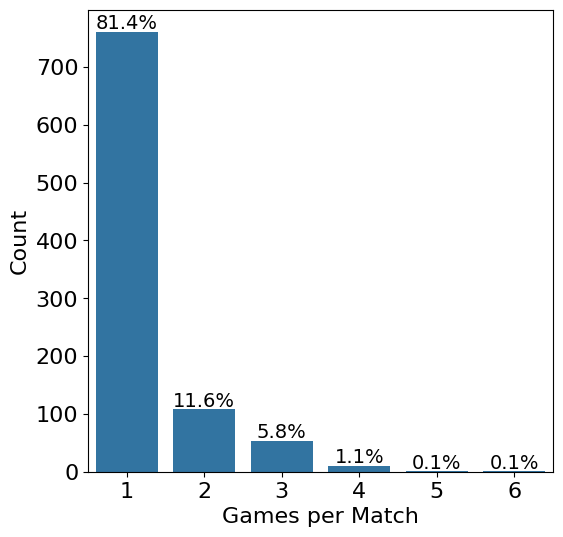

In [ ]:
# plotting count of games per match
fig = plt.figure(figsize=(6, 6))

total = game_df.shape[0]

ax = sns.countplot(data=game_df, x='game_nbr')

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2.,
            height + 5,
            '{:1.1f}%'.format(height/total*100),
            ha="center", size=14)

plt.xlabel('Games per Match')
plt.ylabel('Count')

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, '2.5'),
  Text(1, 0, '3.0'),
  Text(2, 0, '3.5'),
  Text(3, 0, '4.0'),
  Text(4, 0, '4.5'),
  Text(5, 0, '5.0'),
  Text(6, 0, '5.5'),
  Text(7, 0, 'Pro'),
  Text(8, 0, 'Senior Pro')])

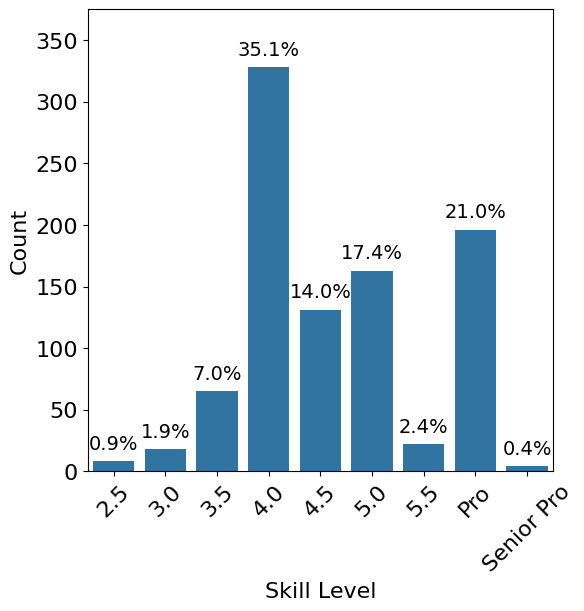

In [ ]:
# plotting count of skill level
fig = plt.figure(figsize=(6, 6))

total = game_df.shape[0]
skill_order = ['2.5', '3.0', '3.5', '4.0', '4.5', '5.0', '5.5',
               'Pro', 'Senior Pro']

ax = sns.countplot(data=game_df, x='skill_lvl', order=skill_order);

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2.,
        height + 10,
            '{:1.1f}%'.format(height/total*100),
        ha="center", size=14)

plt.ylim([0,375])
plt.ylabel('Count')
plt.xlabel('Skill Level')
plt.xticks(rotation=45)

#### Player Data<a id='player_data'></a>

In [ ]:
player_df.head()

,player_id,gender,dom_hand,doubles_dupr,doublesreliabilityscore
0,P699,M,L,NaN,NaN
1,P600,M,R,4.101,5.0
2,P472,M,R,NaN,NaN
3,P320,M,R,NaN,0.0
4,P290,M,L,3.967,1.0


Text(47.120987654321, 0.5, 'Percent')

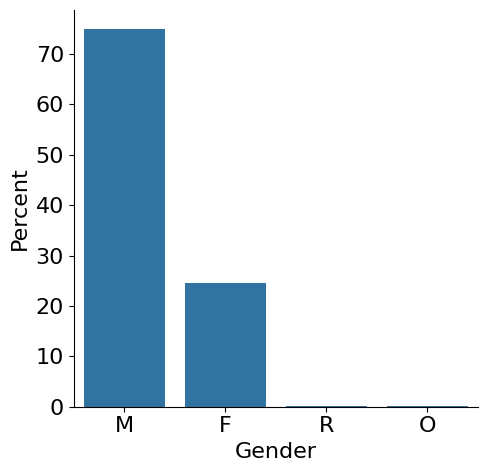

In [ ]:
sns.catplot(data=player_df, x='gender', kind='count', stat='percent')

plt.xlabel('Gender')
plt.ylabel('Percent')

Text(47.11654320987654, 0.5, 'Percent')

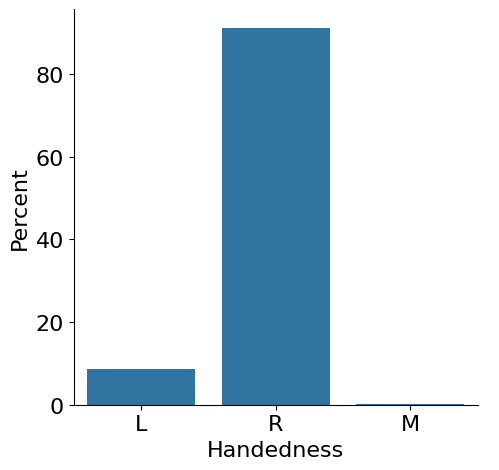

In [ ]:
sns.catplot(data=player_df, x='dom_hand', kind='count', stat='percent')

plt.xlabel('Handedness')
plt.ylabel('Percent')

Text(0, 0.5, 'Count')

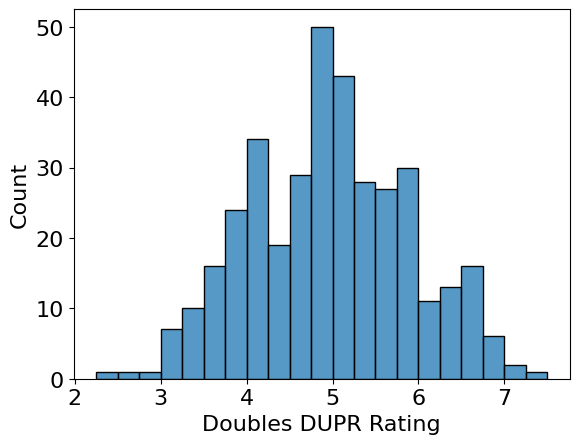

In [ ]:
sns.histplot(data=player_df, x='doubles_dupr', bins=np.arange(2.25, 7.75, 0.25))

plt.xlabel('Doubles DUPR Rating')
plt.ylabel('Count')

#### Shot and Rally Data<a id='shot_rally_data'></a>

In [ ]:
shot_rally_df.head()

,match_id,game_id,rally_id,rally_nbr,rally_len,srv_team_id,rtrn_team_id,w_team_id,shot_id,shot_nbr,...,player_id,loc_x,loc_y,next_loc_x,next_loc_y,ending_type,shot_outcome,rally_outcome,next_shot_type,next_2-shot_type
289847,M99,G178,R7807,65,4,T135,T136,T135,S72059,4,...,P183,6.05,8.08,NaN,NaN,Unforced Error,Unforced Error,Game Over,NaN,NaN
289846,M99,G178,R7807,65,4,T135,T136,T135,S72058,3,...,P182,8.71,-20.58,6.05,8.08,Unforced Error,Winner,Game Over,HB,NaN
289845,M99,G178,R7807,65,4,T135,T136,T135,S72057,2,...,P184,17.53,20.76,8.71,-20.58,Unforced Error,Extend Rally,Game Over,tsDrv,HB
289844,M99,G178,R7807,65,4,T135,T136,T135,S72056,1,...,P181,7.42,-20.94,17.53,20.76,Unforced Error,Start Rally,Game Over,R,tsDrv
289843,M99,G178,R7806,64,4,T135,T136,T135,S72055,4,...,P184,11.56,7.72,NaN,NaN,Unforced Error,Unforced Error,Point,NaN,NaN


Text(48.636543209876564, 0.5, 'Count')

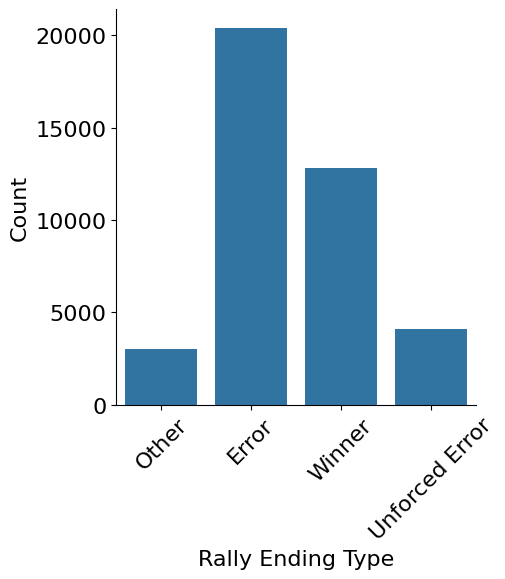

In [ ]:
sns.catplot(data=rally_df, x='ending_type', kind='count')

plt.xticks(rotation=45)
plt.xlabel('Rally Ending Type')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

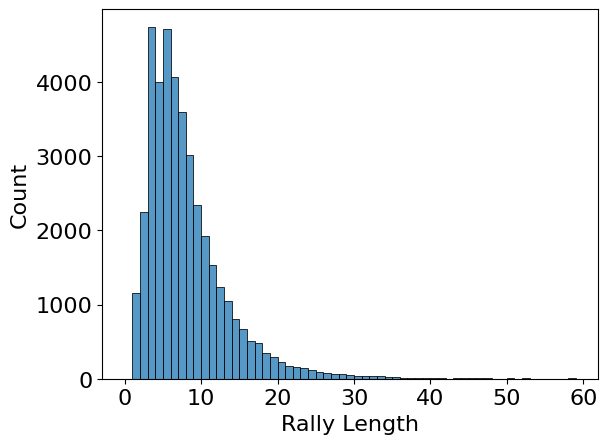

In [ ]:
sns.histplot(data=rally_df, x='rally_len', bins = np.arange(0,60,1))

plt.xlabel('Rally Length')
plt.ylabel('Count')

In [ ]:
shot_df.columns

Index(['shot_id', 'rally_id', 'shot_nbr', 'shot_type', 'player_id', 'loc_x',
       'loc_y', 'next_loc_x', 'next_loc_y'],
      dtype='object')

Text(47.02561728395064, 0.5, 'Count')

<Figure size 2000x400 with 0 Axes>

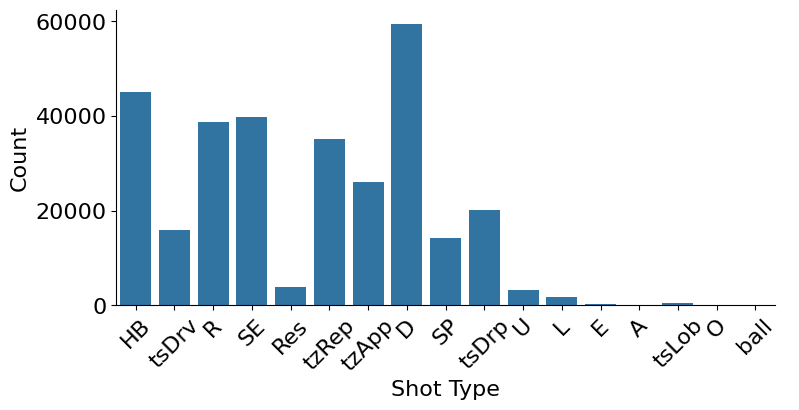

In [ ]:
fig = plt.figure(figsize=(20, 4))

sns.catplot(data=shot_rally_df, x='shot_type', kind='count', height=4, aspect=2)

plt.xticks(rotation=45)
plt.xlabel('Shot Type')
plt.ylabel('Count')

Text(0, 0.5, 'Percent')

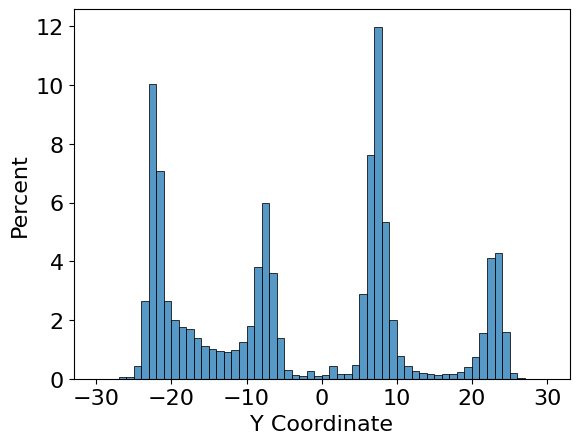

In [ ]:
sns.histplot(data=shot_rally_df, x='loc_y', bins=np.arange(-30, 31, 1), stat='percent')

plt.xlabel('Y Coordinate')
plt.ylabel('Percent')

Text(49.58790004748337, 0.5, 'Percent')

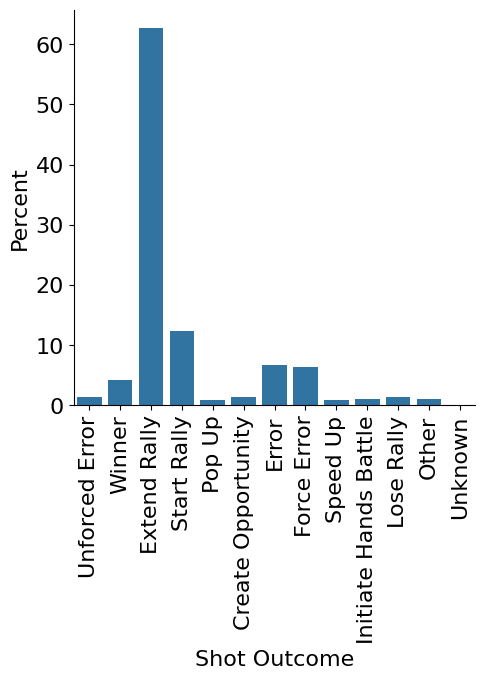

In [ ]:
sns.catplot(data=shot_rally_df, x='shot_outcome', kind='count', stat='percent')

plt.xticks(rotation=90)
plt.xlabel('Shot Outcome')
plt.ylabel('Percent')

Text(67.83139917695475, 0.5, 'Percent')

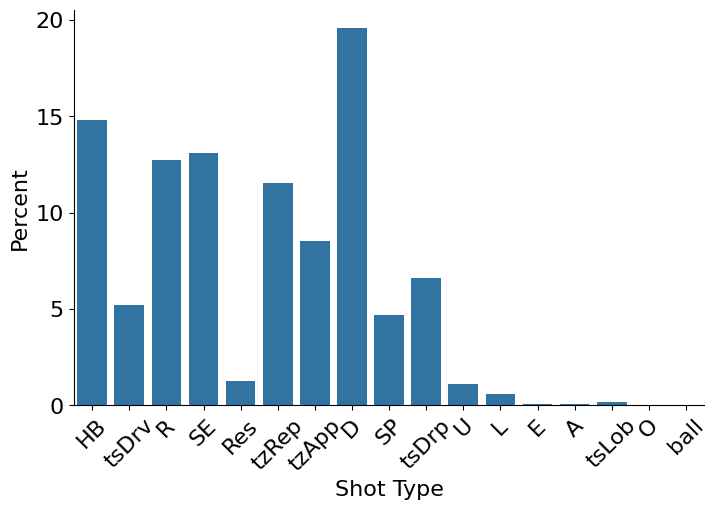

In [ ]:
sns.catplot(data=shot_rally_df, x='shot_type', kind='count', stat='percent', aspect=1.5)

plt.xticks(rotation=45)
plt.xlabel('Shot Type')
plt.ylabel('Percent')

### Bivariate Distributions<a id='bivariate_distributions'></a>

In [ ]:
game_df.head(3)

,game_id,match_id,game_nbr,score_w,score_l,w_team_id,l_team_id,skill_lvl,scoring_type,ball_type,dt_played
0,G347,M219,1,12,10,T311,T310,Pro,STANDARD_DOUBLES,D40,2022-10-25
1,G481,M317,1,5,5,T391,T390,4.0,STANDARD_DOUBLES,U,2023-10-01
2,G361,M227,1,15,9,T159,T321,3.5,STANDARD_DOUBLES,FX40,2023-10-21


In [ ]:
rally_df.head(3)

,rally_id,game_id,match_id,rally_nbr,w_team_id,srv_team_id,srv_player_id,rtrn_team_id,rtrn_player_id,ts_player_id,...,ending_type,ending_player_id,srv_switch_ind,rtrn_switch_ind,srv_team_flipped_ind,rtrn_team_flipped_ind,srv_team_rs_player_id,srv_team_ls_player_id,rtrn_team_rs_player_id,rtrn_team_ls_player_id
0,R8968,G208,M113,6,T152,T152,P202,T155,P70,P202,...,Other,NaN,Y,N,N,N,P203,P202,P70,P205
1,R8963,G208,M113,1,T155,T152,P202,T155,P70,NaN,...,Error,P203,Y,N,N,N,P203,P202,P70,P205
2,R8964,G208,M113,2,T152,T155,P70,T152,P202,P205,...,Error,P205,N,Y,N,N,P70,P205,P203,P202


Text(0, 0.5, 'Percent')

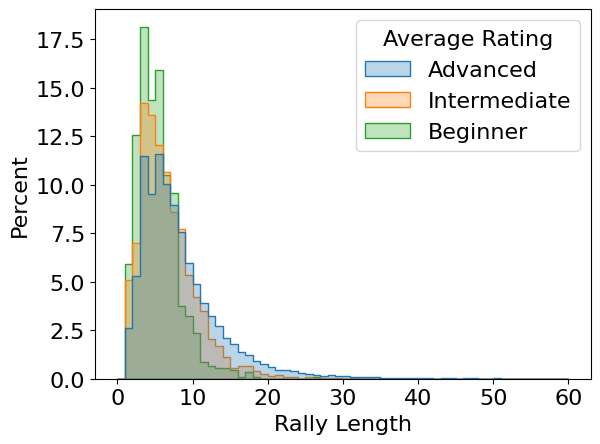

In [ ]:
# Rally length by dupr rating
skill_mapper = {'2.5':'Beginner', '3.0':'Beginner', '3.5':'Intermediate',
                '4.0':'Intermediate', '4.0':'Advanced', '4.5':'Advanced',
                '5.0':'Advanced', '5.5':'Advanced', 'Pro':'Advanced', 'Senior Pro':'Advanced'}
my_df = pd.merge(rally_df, game_df[['game_id', 'skill_lvl']], on='game_id',
                 how='left')
my_df['skill_lvl'] = my_df['skill_lvl'].map(skill_mapper)

ax = sns.histplot(data=my_df, x='rally_len', hue='skill_lvl', stat='percent',
             bins = np.arange(0, 61, 1), alpha=0.3, common_norm=False, element='step')

ax.get_legend().set_title('Average Rating')
plt.xlabel('Rally Length')
plt.ylabel('Percent')

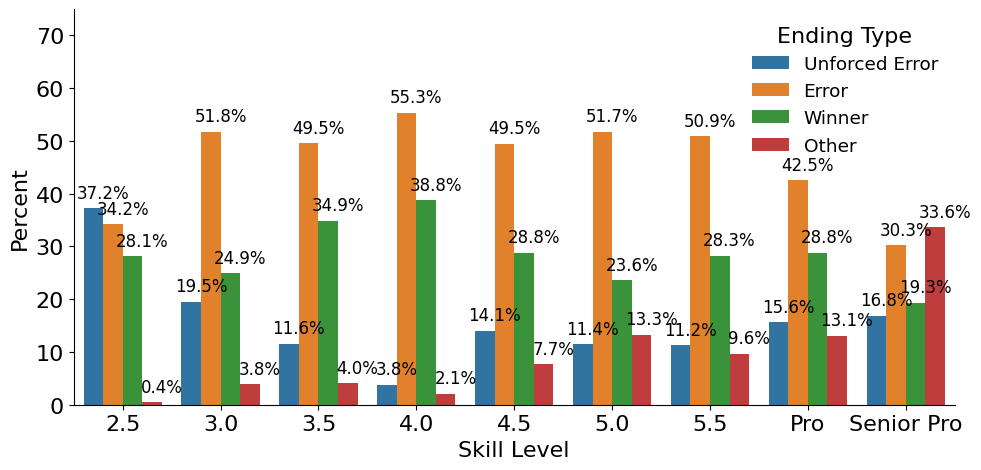

In [ ]:
# Rally ending type by rating
my_df = pd.merge(rally_df, game_df[['game_id', 'skill_lvl']], on='game_id',
                 how='left')[['skill_lvl', 'ending_type']]

x,y = 'skill_lvl', 'ending_type'

my_df = my_df.groupby(x)[y].value_counts(normalize=True)
my_df = my_df.mul(100)
my_df = my_df.rename('Percent').reset_index()

# mask  = [(x in ['2.5', '3.0', '3.5']) for x in my_df['skill_lvl']]
# my_df = my_df[mask]

g = sns.catplot(x=x,y='Percent',hue=y,kind='bar',data=my_df, aspect=2,
                legend='auto', legend_out=False)
g.ax.set_ylim(0,75)
g.ax.set_xlabel('Skill Level')
g.ax.legend(frameon=False, title='Ending Type', fontsize='small')

for i, p in enumerate(g.ax.patches):
    if i < 36:
        g.ax.text(p.get_x() + 0.2,
                p.get_height() + 2,
                f'{p.get_height():.1f}%',
                ha='center', size=12)

In [ ]:
shot_rally_df.head(3)

,match_id,game_id,rally_id,rally_nbr,rally_len,srv_team_id,rtrn_team_id,w_team_id,shot_id,shot_nbr,...,player_id,loc_x,loc_y,next_loc_x,next_loc_y,ending_type,shot_outcome,rally_outcome,next_shot_type,next_2-shot_type
289847,M99,G178,R7807,65,4,T135,T136,T135,S72059,4,...,P183,6.05,8.08,NaN,NaN,Unforced Error,Unforced Error,Game Over,NaN,NaN
289846,M99,G178,R7807,65,4,T135,T136,T135,S72058,3,...,P182,8.71,-20.58,6.05,8.08,Unforced Error,Winner,Game Over,HB,NaN
289845,M99,G178,R7807,65,4,T135,T136,T135,S72057,2,...,P184,17.53,20.76,8.71,-20.58,Unforced Error,Extend Rally,Game Over,tsDrv,HB


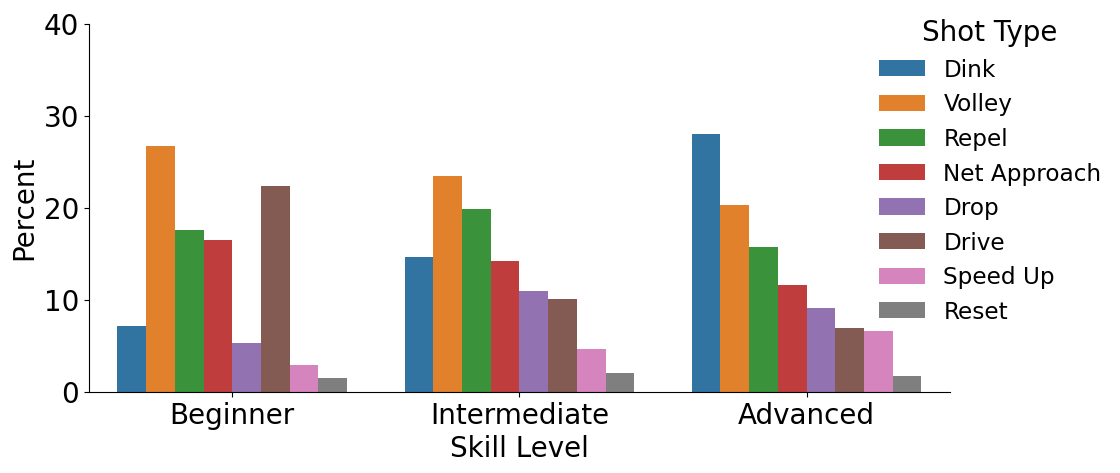

In [ ]:
# shot type vs game skill level, exclusing SE and R
shot_mapper = {'D':'Dink', 'HB':'Volley', 'SE':'Serve', 'R':'Return',
          'tzRep':'Repel', 'tzApp':'Net Approach', 'tsDrp':'Drop', 'tsDrv':'Drive',
          'SP':'Speed Up', 'Res':'Reset', 'U':'U', 'L':'Lob', 'tsLob':'Lob',
          'E':'Volley', 'A':'Speed Up', 'O':'O', 'ball':'ball'}
skill_mapper = {'2.5':'Beginner', '3.0':'Beginner', '3.5':'Intermediate',
                '4.0':'Intermediate', '4.0':'Advanced', '4.5':'Advanced',
                '5.0':'Advanced', '5.5':'Advanced', 'Pro':'Advanced', 'Senior Pro':'Advanced'}

shot_filter = ['HB', 'tsDrv', 'tsDrp', 'tzApp', 'tzRep', 'D', 'SP', 'Res']
mask = [(x in shot_filter) for x in shot_rally_df.shot_type]
my_df = shot_rally_df[['game_id', 'shot_type']][mask]
my_df = pd.merge(my_df,
                 game_df[['game_id', 'skill_lvl']], on='game_id',
                 how='left')[['skill_lvl', 'shot_type']]
my_df['shot_type'] = my_df['shot_type'].map(shot_mapper)
my_df['skill_lvl'] = my_df['skill_lvl'].map(skill_mapper)

x,y = 'skill_lvl', 'shot_type'

my_df = my_df.groupby(x)[y].value_counts(normalize=True)
my_df = my_df.mul(100)
my_df = my_df.rename('Percent').reset_index()

g = sns.catplot(x=x,y='Percent',hue=y,kind='bar',data=my_df, aspect=2,
                legend='auto', legend_out=False, order=['Beginner', 'Intermediate', 'Advanced'])
g.ax.set_ylim(0,40)
g.ax.set_xlabel('Skill Level')
g.ax.legend(frameon=False, title='Shot Type', fontsize='small',
            loc='right', bbox_to_anchor=(1.2, 0.6))

# for i, p in enumerate(g.ax.patches):
#     g.ax.text(p.get_x() + 0.2,
#             p.get_height() + 2,
#             f'{p.get_height():.1f}%',
#             ha='center', size=12)

Text(47.02561728395064, 0.5, 'Count')

<Figure size 2000x400 with 0 Axes>

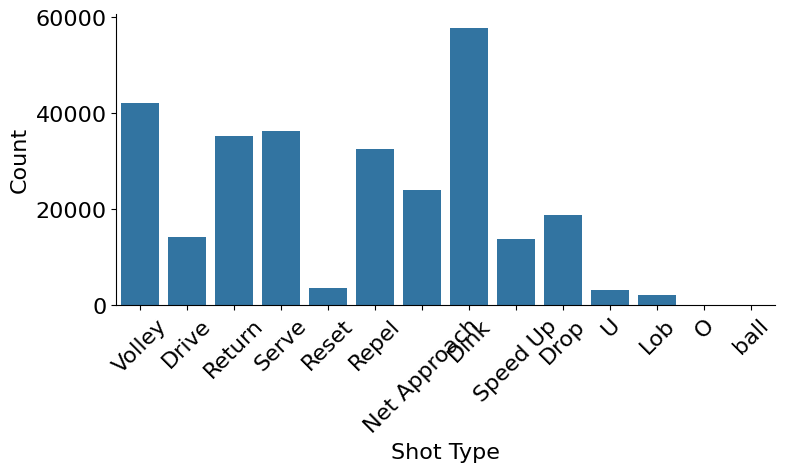

In [ ]:
shot_mapper = {'D':'Dink', 'HB':'Volley', 'SE':'Serve', 'R':'Return',
          'tzRep':'Repel', 'tzApp':'Net Approach', 'tsDrp':'Drop', 'tsDrv':'Drive',
          'SP':'Speed Up', 'Res':'Reset', 'U':'U', 'L':'Lob', 'tsLob':'Lob',
          'E':'Volley', 'A':'Speed Up', 'O':'O', 'ball':'ball'}
skill_mapper = {'2.5':'Beginner', '3.0':'Beginner', '3.5':'Intermediate',
                '4.0':'Intermediate', '4.0':'Advanced', '4.5':'Advanced',
                '5.0':'Advanced', '5.5':'Advanced', 'Pro':'Advanced', 'Senior Pro':'Advanced'}

my_df = shot_rally_df[['game_id', 'shot_type']]
my_df = pd.merge(my_df,
                 game_df[['game_id', 'skill_lvl']], on='game_id',
                 how='left')[['skill_lvl', 'shot_type']]
my_df['shot_type'] = my_df['shot_type'].map(shot_mapper)
my_df['skill_lvl'] = my_df['skill_lvl'].map(skill_mapper)

my_df = my_df[my_df['skill_lvl'] == 'Advanced']

fig = plt.figure(figsize=(20, 4))

sns.catplot(data=my_df, x='shot_type', kind='count', height=4, aspect=2)

plt.xticks(rotation=45)
plt.xlabel('Shot Type')
plt.ylabel('Count')

In [ ]:
from collections import Counter

In [ ]:
Counter(my_df['shot_type'])

Counter({'Volley': 42130,
         'Drive': 14209,
         'Return': 35355,
         'Serve': 36305,
         'Reset': 3554,
         'Repel': 32485,
         'Net Approach': 24039,
         'Dink': 57769,
         'Speed Up': 13784,
         'Drop': 18747,
         'U': 3163,
         'Lob': 2040,
         'O': 1,
         'ball': 6})

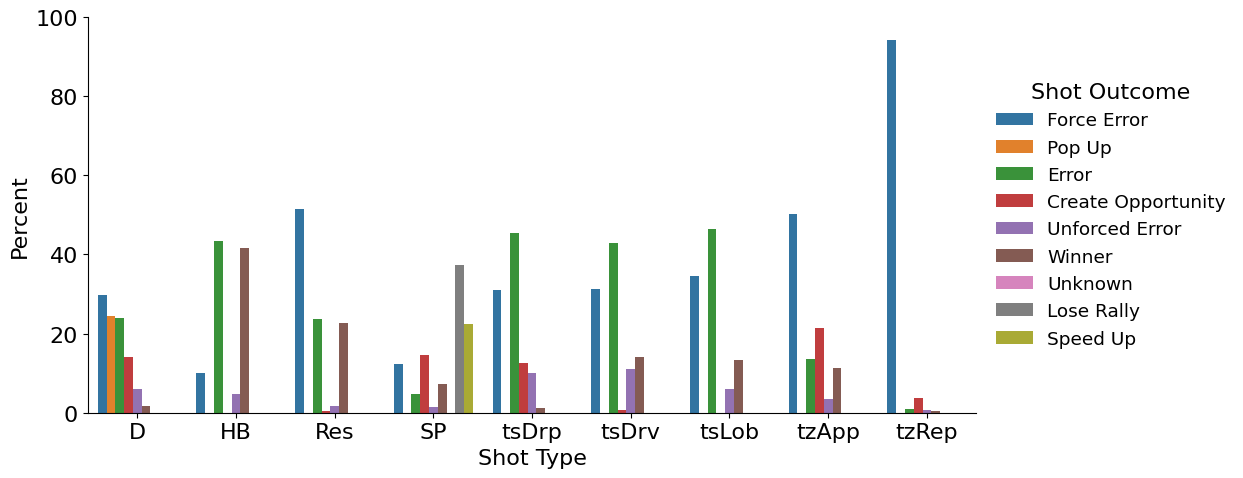

In [ ]:
# shot outcome vs shot type
shot_filter = ['SE', 'R', 'O', 'U', 'E', 'A', 'L', 'ball']
mask = [(x not in shot_filter) for x in shot_rally_df.shot_type]
my_df = shot_rally_df[['shot_type', 'shot_outcome']][mask]
outcome_filter = ['Extend Rally', 'Start Rally', 'Initiate Hands Battle',
                  'Other']
mask = [(x not in outcome_filter) for x in my_df.shot_outcome]
my_df = my_df[mask]

x,y = 'shot_type', 'shot_outcome'

my_df = my_df.groupby(x)[y].value_counts(normalize=True)
my_df = my_df.mul(100)
my_df = my_df.rename('Percent').reset_index()

g = sns.catplot(x=x,y='Percent',hue=y,kind='bar',data=my_df, aspect=2,
                legend='auto', legend_out=False)
g.ax.set_ylim(0,100)
g.ax.set_xlabel('Shot Type')
g.ax.legend(frameon=False, title='Shot Outcome', fontsize='small',
            loc='right', bbox_to_anchor=(1.3, 0.5))

# for i, p in enumerate(g.ax.patches):
#     g.ax.text(p.get_x() + 0.2,
#             p.get_height() + 2,
#             f'{p.get_height():.1f}%',
#             ha='center', size=12)

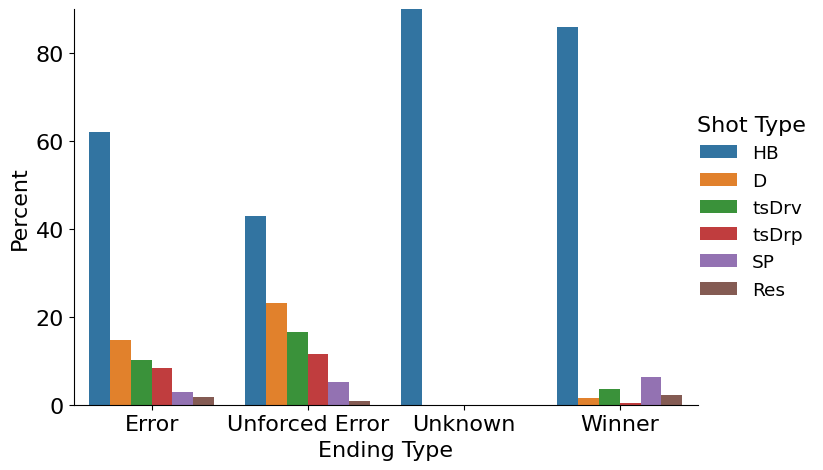

In [ ]:
# rally outcome by shot type
inds = []
cur_rally_id = ''
for i in shot_rally_df.index:
    if shot_rally_df.loc[i, 'rally_id'] != cur_rally_id:
        inds.append(i)
        cur_rally_id = shot_rally_df.loc[i, 'rally_id']

my_df = shot_rally_df.loc[inds][['ending_type', 'shot_type']]

shot_filter = ['SE', 'R', 'O', 'U', 'E', 'A', 'L', 'ball',
               'tzApp', 'tzLob', 'tzRep', 'tsLob']
mask = [(x not in shot_filter) for x in my_df.shot_type]
my_df = my_df[mask]
ending_filter = ['Other']
mask = [(x not in ending_filter) for x in my_df.ending_type]
my_df = my_df[mask]

x,y = 'ending_type', 'shot_type'

my_df = my_df.groupby(x)[y].value_counts(normalize=True)
my_df = my_df.mul(100)
my_df = my_df.rename('Percent').reset_index()

g = sns.catplot(x=x,y='Percent',hue=y,kind='bar',data=my_df, aspect=1.5,
                legend='auto', legend_out=False)
g.ax.set_ylim(0,90)
g.ax.set_xlabel('Ending Type')
g.ax.legend(frameon=False, title='Shot Type', fontsize='small',
            loc='right', bbox_to_anchor=(1.2, 0.5))

# for i, p in enumerate(g.ax.patches):
#     if i < 36:
#         g.ax.text(p.get_x() + 0.2,
#                 p.get_height() + 2,
#                 f'{p.get_height():.1f}%',
#                 ha='center', size=12)

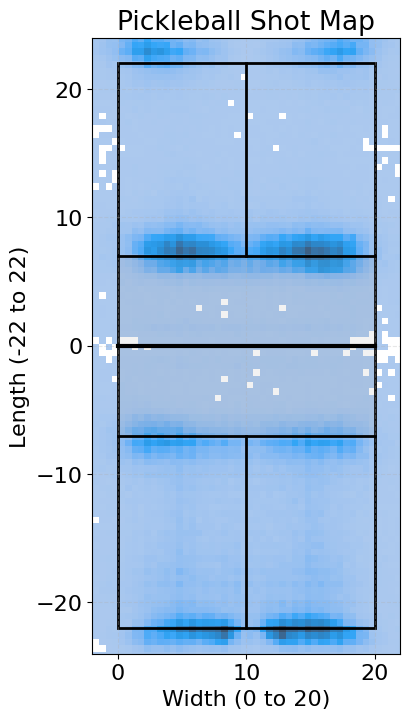

In [ ]:
fig, ax = plt.subplots(figsize=(6, 8))

# Dimensions based on your request
width = 20
half_length = 22
kitchen_offset = 7 # Standard kitchen is 7ft from net

# Plotting shot data first
ax = sns.histplot(data=shot_rally_df, x='loc_x', y='loc_y', binwidth=0.5)

# 1. Draw the Main Court Boundary
# Rectangle( (x_start, y_start), width, height )
court = patches.Rectangle((0, -half_length), width, half_length * 2,
                            linewidth=2, edgecolor='black', facecolor='none')
ax.add_patch(court)

# 2. Draw the Net (Center line at y=0)
ax.plot([0, width], [0, 0], color='black', linewidth=3, label='Net')

# 3. Draw Non-Volley Zone (Kitchen) lines
ax.plot([0, width], [kitchen_offset, kitchen_offset], color='black', linewidth=2)
ax.plot([0, width], [-kitchen_offset, -kitchen_offset], color='black', linewidth=2)

# 4. Draw Center lines (splitting the service courts)
# From top kitchen line to top baseline
ax.plot([width/2, width/2], [kitchen_offset, half_length], color='black', linewidth=2)
# From bottom kitchen line to bottom baseline
ax.plot([width/2, width/2], [-kitchen_offset, -half_length], color='black', linewidth=2)

# 5. Optional: Highlight the Kitchen Area
kitchen_top = patches.Rectangle((0, 0), width, kitchen_offset, color='gray', alpha=0.1)
kitchen_bottom = patches.Rectangle((0, -kitchen_offset), width, kitchen_offset, color='gray', alpha=0.1)
ax.add_patch(kitchen_top)
ax.add_patch(kitchen_bottom)

# Formatting
ax.set_xlim(-2, width + 2)
ax.set_ylim(-half_length - 2, half_length + 2)
ax.set_aspect('equal') # Crucial to keep the court proportions correct
ax.set_title("Pickleball Shot Map")
ax.set_xlabel("Width (0 to 20)")
ax.set_ylabel("Length (-22 to 22)")
ax.legend().remove()

plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

## Data Visualization

In [ ]:
shot_rally_df.head(2)

,match_id,game_id,rally_id,rally_nbr,rally_len,srv_team_id,rtrn_team_id,w_team_id,shot_id,shot_nbr,...,player_id,loc_x,loc_y,next_loc_x,next_loc_y,ending_type,shot_outcome,rally_outcome,next_shot_type,next_2-shot_type
289847,M99,G178,R7807,65,4,T135,T136,T135,S72059,4,...,P183,6.05,8.08,NaN,NaN,Unforced Error,Unforced Error,Game Over,NaN,NaN
289846,M99,G178,R7807,65,4,T135,T136,T135,S72058,3,...,P182,8.71,-20.58,6.05,8.08,Unforced Error,Winner,Game Over,HB,NaN


In [ ]:
shot_rally_df = shot_rally_df.sort_values(by=['match_id', 'game_id', 'rally_nbr', 'shot_nbr'])

In [ ]:
# I want to graphically draw a pickleball court
def draw_pickleball_court(df):
    fig, ax = plt.subplots(figsize=(6, 8))

    # Dimensions based on your request
    width = 20
    half_length = 22
    kitchen_offset = 7 # Standard kitchen is 7ft from net

    # 1. Draw the Main Court Boundary
    # Rectangle( (x_start, y_start), width, height )
    court = patches.Rectangle((0, -half_length), width, half_length * 2,
                              linewidth=2, edgecolor='black', facecolor='none')
    ax.add_patch(court)

    # 2. Draw the Net (Center line at y=0)
    ax.plot([0, width], [0, 0], color='black', linewidth=3)

    # 3. Draw Non-Volley Zone (Kitchen) lines
    ax.plot([0, width], [kitchen_offset, kitchen_offset], color='black', linewidth=2)
    ax.plot([0, width], [-kitchen_offset, -kitchen_offset], color='black', linewidth=2)

    # 4. Draw Center lines (splitting the service courts)
    # From top kitchen line to top baseline
    ax.plot([width/2, width/2], [kitchen_offset, half_length], color='black', linewidth=2)
    # From bottom kitchen line to bottom baseline
    ax.plot([width/2, width/2], [-kitchen_offset, -half_length], color='black', linewidth=2)

    # 5. Optional: Highlight the Kitchen Area
    kitchen_top = patches.Rectangle((0, 0), width, kitchen_offset, color='gray', alpha=0.1)
    kitchen_bottom = patches.Rectangle((0, -kitchen_offset), width, kitchen_offset, color='gray', alpha=0.1)
    ax.add_patch(kitchen_top)
    ax.add_patch(kitchen_bottom)

    # mappings for shot types
    shot_color_mapper = {'SE':'k', 'R':'k', 'tsDrp':'blue', 'tsDrv':'red', 'D':'gray',
                     'tzApp':'skyblue', 'tzRep':'tomato', 'HB':'magenta', 'SP':'red',
                     'L':'green', 'tsLob':'green', 'U':'k', 'Res':'blue', 'E':'magenta', 'A':'red', 'ball':'k'}
    shot_label = {'SE':'Serve', 'R':'Return', 'tsDrp':'Drop', 'tsDrv':'Drive', 'D':'Dink',
                  'tzApp':'Net Approach', 'tzRep':'Repel', 'HB':'Volley', 'SP':'Speed Up',
                  'L':'Lob', 'tsLob':'Lob', 'U':'Unknown', 'Res':'Reset', 'E':'Erne', 'A':'ATP', 'ball':'ball'}

    # Example: Plotting shot data
    # Let's say you have a list of (x, y) coordinates
    shots_x = list(df['loc_x'])
    shots_y = list(df['loc_y'])
    shot_types = list(df['shot_type'])
    shot_outcome = list(df['shot_outcome'])
    for i in range(len(shots_x)):
        marker = '$'+str(i+1)+'$'
        if shot_outcome[i] in ['Error', 'Unforced Error']: # this marker case is not tested
            marker = 'x'
        ax.scatter(shots_x[i], shots_y[i], s=100, marker=marker,
                   color=shot_color_mapper[shot_types[i]],
                   label=shot_label[shot_types[i]], zorder=5)

    # Formatting
    ax.set_xlim(-5, width + 5)
    ax.set_ylim(-half_length - 5, half_length + 5)
    ax.set_aspect('equal') # Crucial to keep the court proportions correct
    ax.set_xlabel("Width (20 ft)")
    ax.set_ylabel("Length (44 ft)")
    ax.legend(frameon=False, fontsize='small',
            loc='right', bbox_to_anchor=(1.65, 0.5))

    # plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

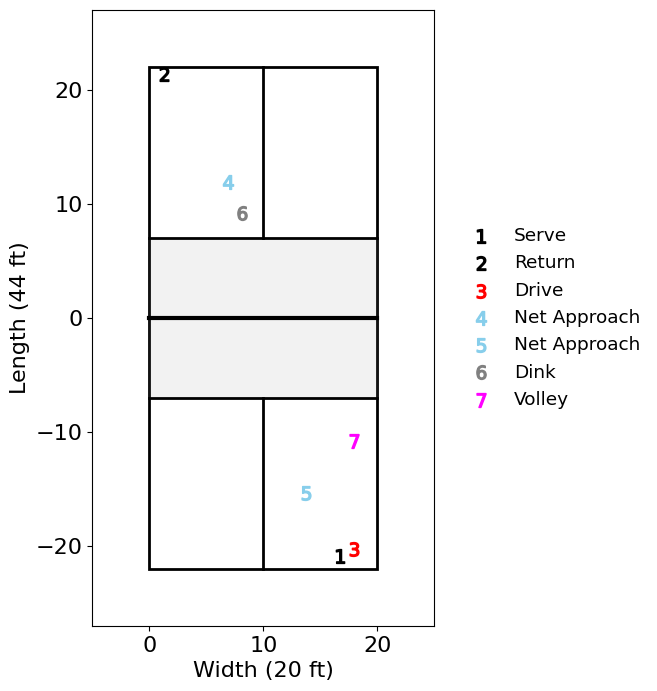

In [ ]:
draw_pickleball_court(shot_rally_df[shot_rally_df['rally_id'] == 'R7804'])

In [ ]:
shot_rally_df[shot_rally_df['rally_len'] == 7]['rally_id'].unique()

array(['R827', 'R7926', 'R7928', ..., 'R7782', 'R7786', 'R7804'],
      dtype=object)

In [ ]:
# R7937 won point on soft game, unforced dink error on opposing side
# R7804 won point by being aggressive, tsDrv, reset, then volley winner
# R7762 lost point, made tsDrp
shot_rally_df[shot_rally_df['rally_id'] == 'R7804']

,match_id,game_id,rally_id,rally_nbr,rally_len,srv_team_id,rtrn_team_id,w_team_id,shot_id,shot_nbr,...,player_id,loc_x,loc_y,next_loc_x,next_loc_y,ending_type,shot_outcome,rally_outcome,next_shot_type,next_2-shot_type
289825,M99,G178,R7804,62,7,T135,T136,T135,S72037,1,...,P181,16.70,-20.85,1.27,21.40,Winner,Start Rally,Point,R,tsDrv
289826,M99,G178,R7804,62,7,T135,T136,T135,S72038,2,...,P183,1.27,21.40,17.90,-20.30,Winner,Extend Rally,Point,tsDrv,tzApp
289827,M99,G178,R7804,62,7,T135,T136,T135,S72039,3,...,P181,17.90,-20.30,6.87,11.94,Winner,Extend Rally,Point,tzApp,tzApp
289828,M99,G178,R7804,62,7,T135,T136,T135,S72040,4,...,P183,6.87,11.94,13.76,-15.34,Winner,Extend Rally,Point,tzApp,D
289829,M99,G178,R7804,62,7,T135,T136,T135,S72041,5,...,P181,13.76,-15.34,8.16,9.19,Winner,Create Opportunity,Point,D,HB
289830,M99,G178,R7804,62,7,T135,T136,T135,S72042,6,...,P183,8.16,9.19,17.90,-10.84,Winner,Pop Up,Point,HB,NaN
289831,M99,G178,R7804,62,7,T135,T136,T135,S72043,7,...,P181,17.90,-10.84,NaN,NaN,Winner,Winner,Point,NaN,NaN


In [ ]:
shot_rally_df[shot_rally_df['game_id'] == 'G178'][['game_id', 'rally_id', 'rally_nbr', 'rally_len', 'shot_nbr', 'shot_type', 'shot_outcome', 'rally_outcome']][150:200]

,game_id,rally_id,rally_nbr,rally_len,shot_nbr,shot_type,shot_outcome,rally_outcome
289367,G178,R7760,18,16,6,tzRep,Extend Rally,Point
289368,G178,R7760,18,16,7,D,Extend Rally,Point
289369,G178,R7760,18,16,8,D,Extend Rally,Point
289370,G178,R7760,18,16,9,D,Extend Rally,Point
289371,G178,R7760,18,16,10,D,Extend Rally,Point
289372,G178,R7760,18,16,11,D,Extend Rally,Point
289373,G178,R7760,18,16,12,D,Extend Rally,Point
289374,G178,R7760,18,16,13,D,Extend Rally,Point
289375,G178,R7760,18,16,14,D,Extend Rally,Point
289376,G178,R7760,18,16,15,D,Force Error,Point


In [ ]:
shot_rally_df[shot_rally_df.rally_id == 'R7805'][['shot_nbr', 'shot_type']]

,shot_nbr,shot_type
289832,1,SE
289833,2,R
289834,3,tsDrv
289835,4,tzRep
289836,5,tzApp
289837,6,tzRep
289838,7,Res
289839,8,HB


In [ ]:
shot_rally_df.shot_outcome.unique()

array(['Start Rally', 'Extend Rally', 'Other', 'Unforced Error', 'Winner',
       'Lose Rally', 'Initiate Hands Battle', 'Create Opportunity',
       'Pop Up', 'Speed Up', 'Force Error', 'Error', 'Unknown'],
      dtype=object)

In [ ]:
df_processed = pd.read_csv(data_path+'processed')